# Week 1: Course Setup and Introduction to GeoAI for Disaster Management

## Overview
This notebook introduces the course structure, required tools, and the role of GeoAI in disaster management. Students will verify their Python environment, review the course workflow, and explore example geospatial and disaster-inspired visualizations.

## Learning Objectives
- Understand the purpose and scope of the course
- Set up the Python environment for weekly activities
- Recognize how AI and geospatial data support disaster management
- Load and visualize sample data in Python
- Create a reusable folder structure for the rest of the course

## Expected Outcome
By the end of this notebook, you should have a working environment and a clear understanding of how this course connects AI, geospatial data, and disaster applications.

## 1. Course Workflow

This GitHub-based course is designed around a weekly pattern:

1. **Read** the background and objectives
2. **Run** the notebook cells
3. **Inspect** the outputs and visualizations
4. **Modify** selected code blocks
5. **Submit** your weekly work or reflections

Later weeks will introduce:
- remote sensing data
- machine learning and computer vision
- surface water detection
- urban flood intelligence
- disaster response analytics
- digital twin integration

Week 1 focuses only on **setup, orientation, and foundational context**.

In [2]:
# Core imports used in Week 1
from pathlib import Path
import sys
import platform
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Environment Check

Run the next cell to confirm that your Python environment is ready.
It checks:
- Python version
- operating system
- availability of common packages used later in the course

In [3]:
required_packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "jupyter",
]

print("Python version :", sys.version.split()[0])
print("Platform       :", platform.platform())
print("-" * 50)

for pkg in required_packages:
    module_name = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        module = importlib.import_module(module_name)
        version = getattr(module, "__version__", "version not available")
        print(f"[OK] {pkg:<12} -> {version}")
    except Exception:
        print(f"[MISSING] {pkg}")

Python version : 3.12.12
Platform       : Linux-6.6.113+-x86_64-with-glibc2.35
--------------------------------------------------
[OK] numpy        -> 2.0.2
[OK] pandas       -> 2.2.2
[OK] matplotlib   -> 3.10.0
[OK] scikit-learn -> 1.6.1
[OK] jupyter      -> version not available


### Optional packages for later weeks

Later modules may use geospatial and deep learning tools such as:
- `rasterio`
- `geopandas`
- `torch`
- `tensorflow`
- `opencv-python`
- `ultralytics`

You do **not** need to install everything in Week 1. Start simple and expand as needed.

## 3. Create a Reusable Course Folder Structure

A consistent directory structure makes the course easier to manage.
This will create local folders for data, outputs, figures, and submissions.

In [4]:
project_root = Path("geoai_disaster_course")
folders = [
    "data/raw",
    "data/processed",
    "figures",
    "outputs",
    "submissions",
    "references",
]

for folder in folders:
    (project_root / folder).mkdir(parents=True, exist_ok=True)

print(f"Created project root at: {project_root.resolve()}")
print("Folders:")
for folder in folders:
    print(" -", project_root / folder)

Created project root at: /content/geoai_disaster_course
Folders:
 - geoai_disaster_course/data/raw
 - geoai_disaster_course/data/processed
 - geoai_disaster_course/figures
 - geoai_disaster_course/outputs
 - geoai_disaster_course/submissions
 - geoai_disaster_course/references


## 4. What is GeoAI in Disaster Management?

**GeoAI** combines geospatial data, machine learning, and computational analysis to support spatial decision-making.

In disaster management, GeoAI can help with:
- **Preparedness:** identifying vulnerable regions before an event
- **Rapid assessment:** mapping flood extent, blocked roads, or damaged assets during an event
- **Post-disaster assessment:** estimating damage, loss, and recovery priorities after an event

### Example application areas
- flood extent mapping from satellite imagery
- vehicle-based flood severity estimation from street imagery
- building damage assessment from aerial or satellite images
- risk maps for planners and emergency teams
- digital twin integration for operational awareness

## 5. A Simple Visual of the Disaster Workflow

The next cell creates a simple conceptual diagram of the three disaster phases used throughout the course.

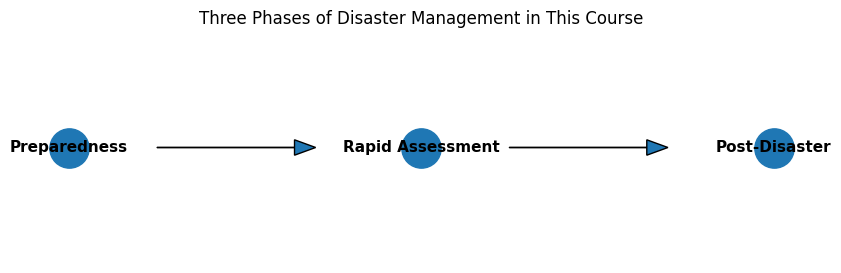

In [5]:
phases = ["Preparedness", "Rapid Assessment", "Post-Disaster"]
x = np.arange(len(phases))
y = [1, 1, 1]

plt.figure(figsize=(10, 3))
plt.scatter(x, y, s=800)
for i, phase in enumerate(phases):
    plt.text(i, 1, phase, ha="center", va="center", fontsize=11, weight="bold")
for i in range(len(phases)-1):
    plt.arrow(i + 0.25, 1, 0.45, 0, length_includes_head=True,
              head_width=0.04, head_length=0.06)

plt.ylim(0.7, 1.3)
plt.yticks([])
plt.xticks([])
plt.title("Three Phases of Disaster Management in This Course")
plt.box(False)
plt.show()

## 6. Sample Geospatial-Style Visualization

To keep Week 1 lightweight, we will generate a **synthetic flood-risk surface** instead of using a large real dataset.
This helps students practice working with raster-like arrays before moving into remote sensing data in later weeks.

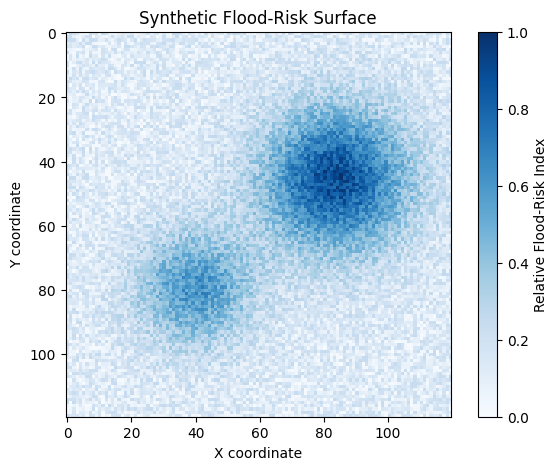

In [6]:
np.random.seed(42)

grid_size = 120
x = np.linspace(-3, 3, grid_size)
y = np.linspace(-3, 3, grid_size)
X, Y = np.meshgrid(x, y)

risk_surface = (
    0.55 * np.exp(-((X - 1.2)**2 + (Y + 0.7)**2) / 1.3)
    + 0.35 * np.exp(-((X + 1.0)**2 + (Y - 1.0)**2) / 0.8)
    + 0.18 * np.random.rand(grid_size, grid_size)
)

risk_surface = (risk_surface - risk_surface.min()) / (risk_surface.max() - risk_surface.min())

plt.figure(figsize=(7, 5))
plt.imshow(risk_surface, cmap="Blues")
plt.colorbar(label="Relative Flood-Risk Index")
plt.title("Synthetic Flood-Risk Surface")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.show()

### Interpretation
Even though the image above is synthetic, it behaves like a simple spatial raster:
- darker or lighter regions can represent different risk levels
- every pixel has a value
- we can threshold, classify, or segment the image later

This idea is important because many GeoAI workflows begin by converting spatial information into arrays, grids, masks, or tiles that models can analyze.

## 7. Example of AI-Supported Disaster Tasks

The next cell creates a small table linking disaster questions to AI task types.

In [7]:
tasks = pd.DataFrame({
    "Disaster Question": [
        "Where is the flooded area?",
        "How severe is flooding around vehicles?",
        "Which buildings are damaged?",
        "Which regions are most vulnerable before a storm?"
    ],
    "AI Task Type": [
        "Semantic segmentation",
        "Object detection + classification",
        "Damage detection / classification",
        "Risk modeling / prediction"
    ],
    "Typical Data Source": [
        "Satellite imagery",
        "Street-level imagery",
        "Aerial or satellite imagery",
        "Multi-source geospatial data"
    ]
})

tasks

,Disaster Question,AI Task Type,Typical Data Source
0,Where is the flooded area?,Semantic segmentation,Satellite imagery
1,How severe is flooding around vehicles?,Object detection + classification,Street-level imagery
2,Which buildings are damaged?,Damage detection / classification,Aerial or satellite imagery
3,Which regions are most vulnerable before a storm?,Risk modeling / prediction,Multi-source geospatial data


## 8. Mini Exercise

Try editing the next cell:
1. change the names of the disaster questions
2. add one more row for a new application
3. rerun the cell and inspect the updated table

In [8]:
student_tasks = pd.DataFrame({
    "Disaster Question": [
        "Where is the flooded area?",
        "How severe is flooding around vehicles?",
    ],
    "AI Task Type": [
        "Semantic segmentation",
        "Object detection + classification",
    ],
    "Typical Data Source": [
        "Satellite imagery",
        "Street-level imagery",
    ]
})

student_tasks

,Disaster Question,AI Task Type,Typical Data Source
0,Where is the flooded area?,Semantic segmentation,Satellite imagery
1,How severe is flooding around vehicles?,Object detection + classification,Street-level imagery


## 9. Weekly Reflection

Answer the following in your own words:

1. What is GeoAI?
2. Why is geospatial context important in disaster management?
3. What is one disaster problem you would like to study in this course?
4. Which data source interests you most: satellite, UAV, street imagery, or environmental data?

You can write your answers in the next markdown cell.

### Student Reflection
_Write your responses here._

## 10. Week 1 Assignment

Complete the following:
- run all cells successfully
- create the folder structure
- modify the mini exercise table
- write a short reflection
- save the notebook with your outputs

## Key Takeaway

Week 1 establishes the foundation for the course. You now have:
- a working notebook structure
- a project folder layout
- a basic understanding of GeoAI in disaster management
- initial practice with visualization and structured analysis

In Week 2, the course will move into **disaster data sources and geospatial visualization**.

## Optional Challenge

Create a second synthetic raster by changing:
- the random seed
- the hotspot locations
- the intensity values

Then compare both results and describe how the spatial pattern changed.